3-2강


# 선형회귀 파이토치로 짜기

https://www.youtube.com/watch?v=WWurhDWEznw&list=PL_iJu012NOxdhFmM2aw6bwpZTMFdsPxws&index=9




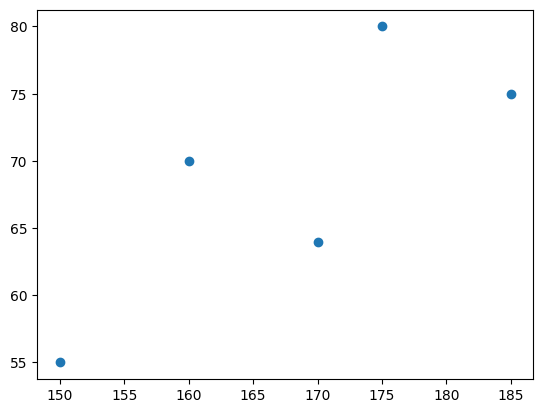

In [ ]:
import torch
import matplotlib.pyplot as plt

# 데이터 입력
x = torch.tensor([150, 160, 170, 175, 185.]) # 키
y = torch.tensor([55, 70, 64, 80, 75.]) # 몸무게
N = len(x)
plt.plot(x,y,'o')

- 아래에 초깃값은 아무렇게나 일단 세팅한거니 당연히 안좋음

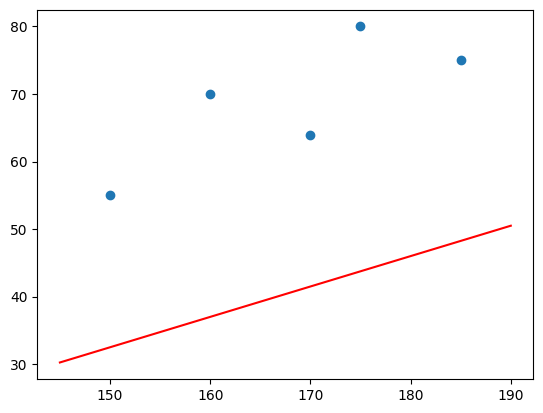

In [ ]:
# 초깃값 설정
a = 0.45
b = -35
x_plot=torch.linspace(145,190,100)
y_plot=a * x_plot + b

plt.plot(x,y,'o')
plt.plot(x_plot,y_plot,'r')

- 일단 a, b를 일정 범위 안에 **다 해보면서** MSE로 loss를 구해보기 (GD는 나중에 씀)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


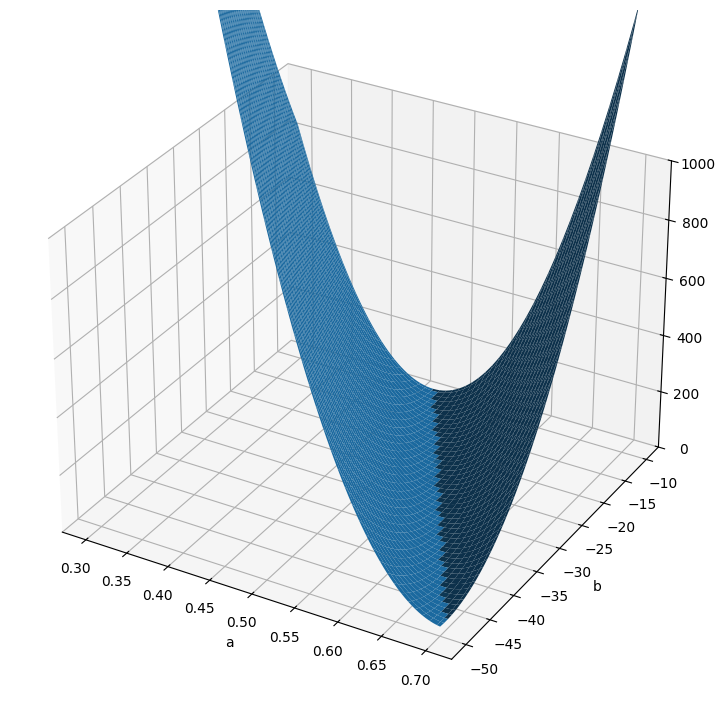

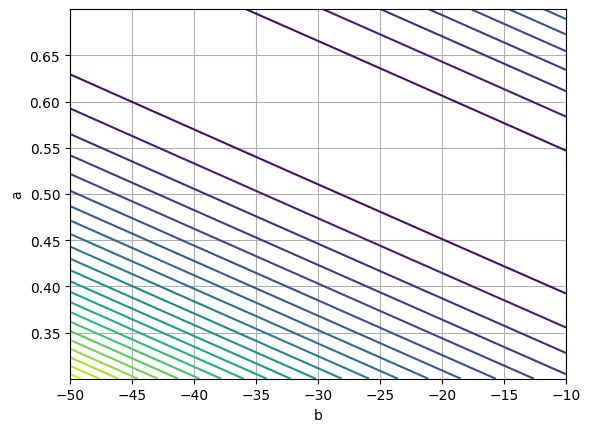

In [ ]:
# a,b 를 바꿔가면서 Loss 값을 일일히 구해서 가장 작아지게 하는 a,b를 선정

a = 0.5 + torch.linspace(-0.2,0.2,100) # 0.3 ~ 0.7
b = -30 + torch.linspace(-20,20,100) # -50 ~ 10
# 위 값들에 대해서 일일히 다 구해보기

L=torch.zeros(len(a),len(b)) # axb 크기의 행렬 생성

for i in range(len(a)):
    for j in range(len(b)):
        # 각 a,b에 대한 MSE를(Loss) 다 구해보기.
        for n in range(N):
            L[i,j] = L[i,j] + (y[n] - (a[i]*x[n]+b[j]))**2

L = L/N # MSE

# 3D plot 시각화
plt.figure(figsize=[10, 9])
ax = plt.axes(projection="3d")
A, B = torch.meshgrid(a,b)
ax.plot_surface(A,B,L);
ax.set_xlabel('a'); ax.set_ylabel('b')
ax.set_zlim([0, 1000])

plt.figure()
plt.contour(b,a,L,30) # 첫 번째 인자가 가로 축, 두 번째 인자가 세로 축이라서
plt.xlabel('b'); plt.ylabel('a'); plt.grid()

- 위 그래프에서 각각 a,b 값이 얼마 정도일 때 Loss가 최소인지 볼 수 있다.



- 위에서 구한 L 행렬에 대해서 최솟값을 찾아서 적용

In [ ]:
print(torch.min(L))
a_opt = A[L==torch.min(L)]
b_opt = B[L==torch.min(L)]
print(f"optimal a = {a_opt}")
print(f"optimal b = {b_opt}")

tensor(29.0315)
optimal a = tensor([0.5626])
optimal b = tensor([-25.7576])


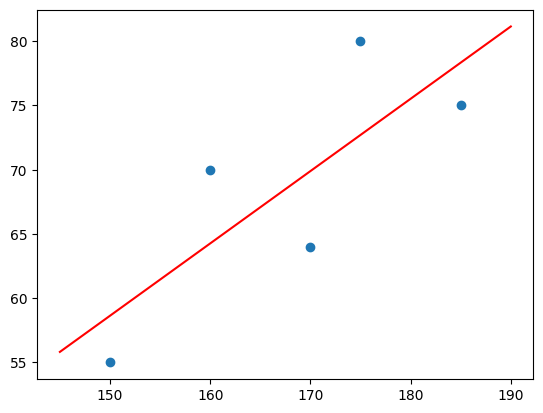

In [ ]:
x_plot=torch.linspace(145,190,100)
y_plot=a_opt * x_plot + b_opt
plt.plot(x,y,'o')
plt.plot(x_plot,y_plot,'r')

- 이거는 그냥 이걸 더 예쁘게 보여줄 수 있는 툴이 있다를 보여줌.

마우스로 드래그하여 움직이게하기 가능.

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Surface(x=b, y=a, z=L, colorscale="viridis", opacity=0.5)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
fig.update_layout(title='Loss', width=700, height=600,
                  scene = dict( xaxis_title='b', yaxis_title='a', zaxis_title='Loss', zaxis=dict(nticks=20, range=[0,1000]) ))

## Gradient Descent

Epoch: 1, train loss: 826.2250
Weight: 0.4785, Bias: -34.9998


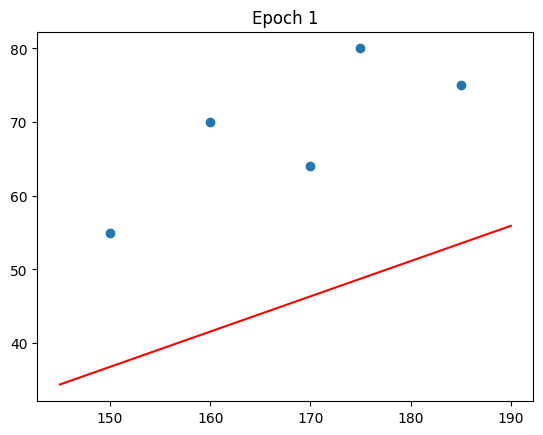

--------------------
Epoch: 2, train loss: 578.0414
Weight: 0.5022, Bias: -34.9997


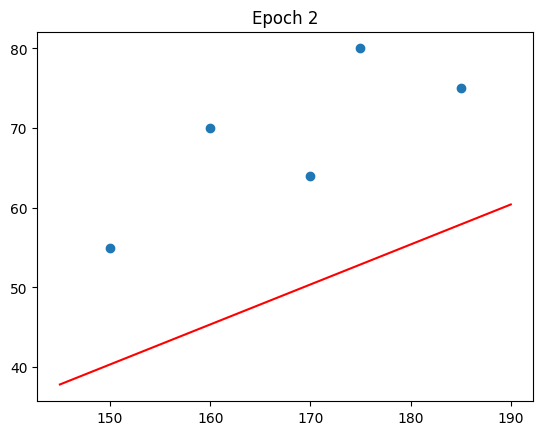

--------------------
Epoch: 3, train loss: 407.1602
Weight: 0.5218, Bias: -34.9996


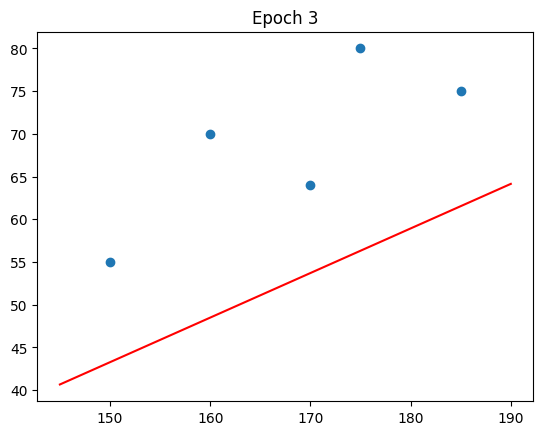

--------------------
Epoch: 4, train loss: 289.5042
Weight: 0.5381, Bias: -34.9995


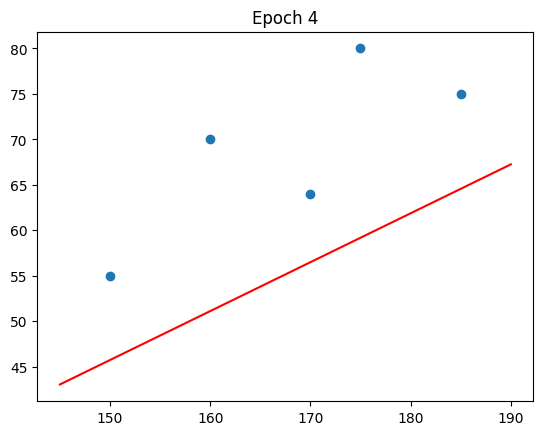

--------------------
Epoch: 5, train loss: 208.4954
Weight: 0.5517, Bias: -34.9994


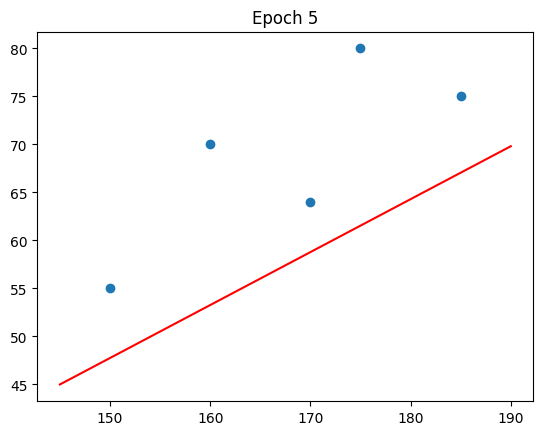

--------------------
Epoch: 6, train loss: 152.7187
Weight: 0.5629, Bias: -34.9993


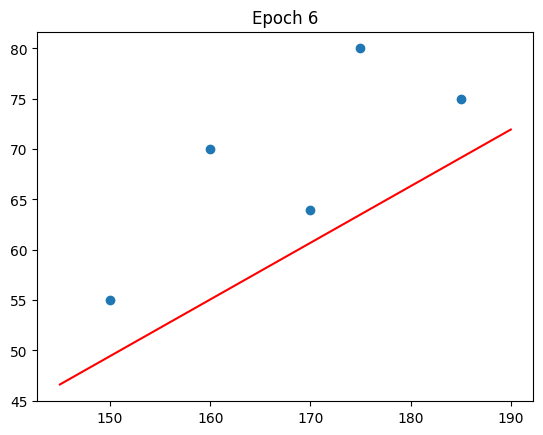

--------------------
Epoch: 7, train loss: 114.3153
Weight: 0.5722, Bias: -34.9993


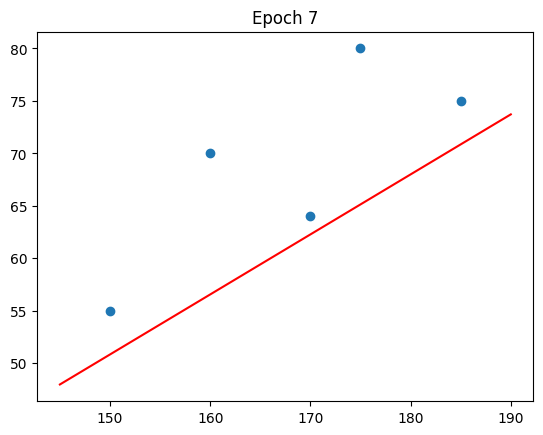

--------------------
Epoch: 8, train loss: 87.8735
Weight: 0.5799, Bias: -34.9992


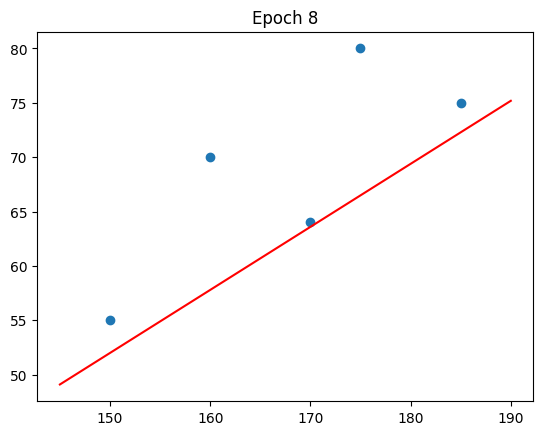

--------------------
Epoch: 9, train loss: 69.6676
Weight: 0.5863, Bias: -34.9992


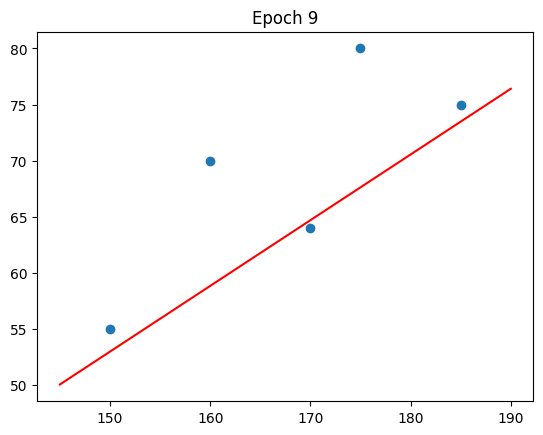

--------------------
Epoch: 10, train loss: 57.1324
Weight: 0.5917, Bias: -34.9992


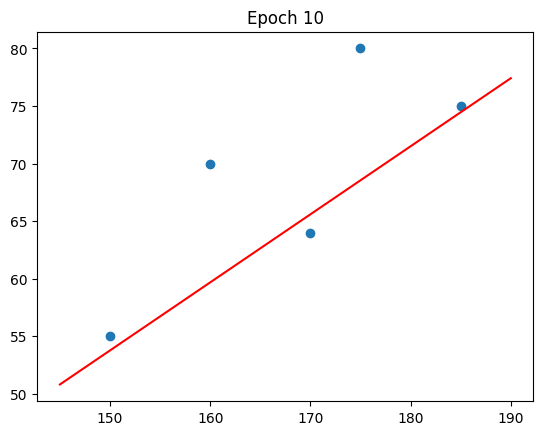

--------------------
Epoch: 11, train loss: 48.5017
Weight: 0.5961, Bias: -34.9991


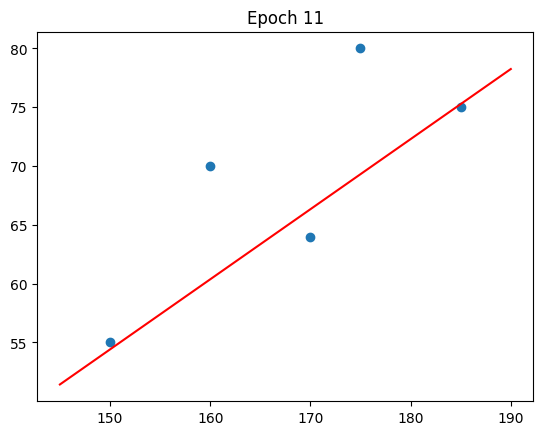

--------------------
Epoch: 12, train loss: 42.5591
Weight: 0.5997, Bias: -34.9991


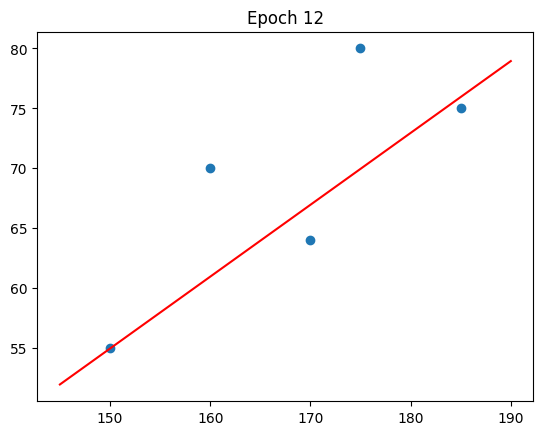

--------------------
Epoch: 13, train loss: 38.4676
Weight: 0.6028, Bias: -34.9991


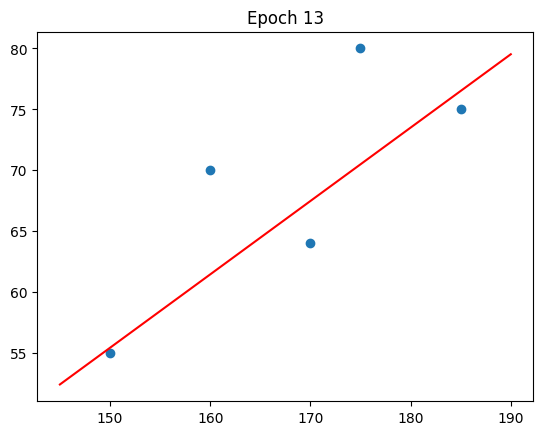

--------------------
Epoch: 14, train loss: 35.6504
Weight: 0.6053, Bias: -34.9991


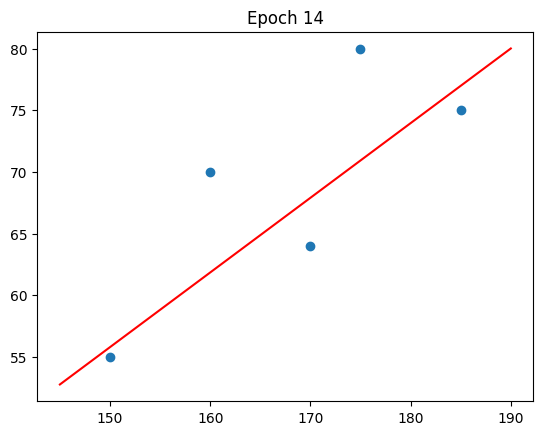

--------------------
Epoch: 15, train loss: 33.7107
Weight: 0.6074, Bias: -34.9991


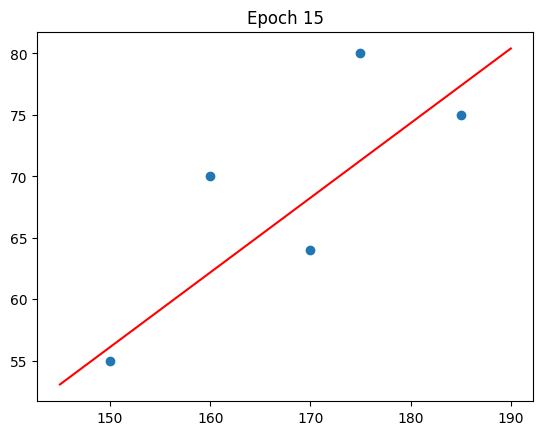

--------------------
Epoch: 16, train loss: 32.3752
Weight: 0.6091, Bias: -34.9991


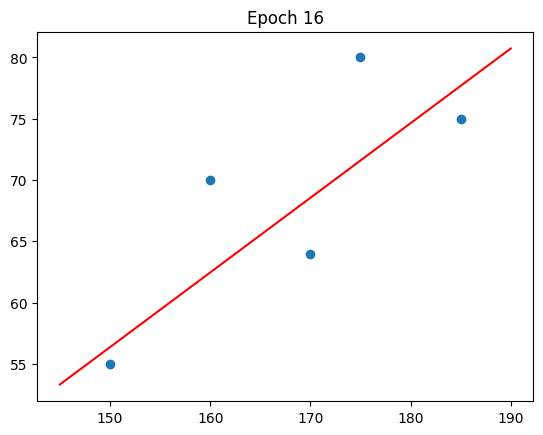

--------------------
Epoch: 17, train loss: 31.4557
Weight: 0.6106, Bias: -34.9990


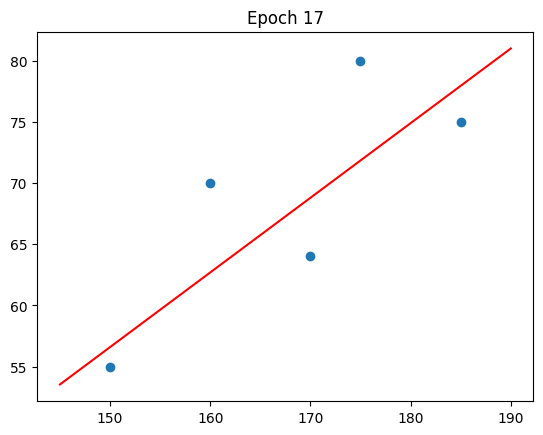

--------------------
Epoch: 18, train loss: 30.8226
Weight: 0.6118, Bias: -34.9990


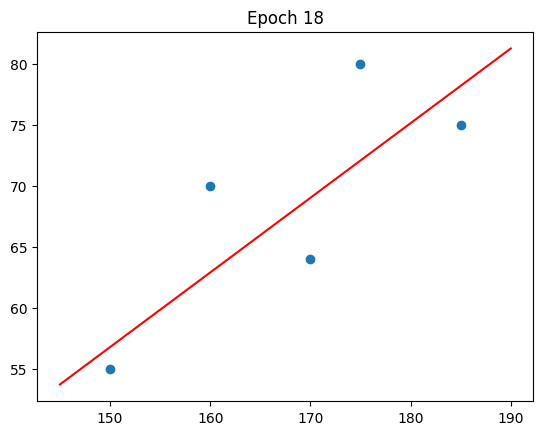

--------------------
Epoch: 19, train loss: 30.3866
Weight: 0.6127, Bias: -34.9990


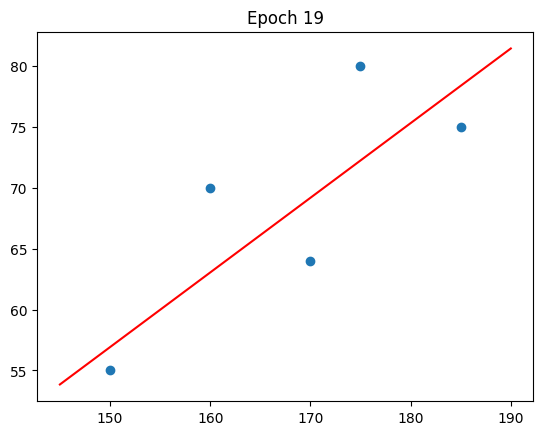

--------------------
Epoch: 20, train loss: 30.0865
Weight: 0.6136, Bias: -34.9990


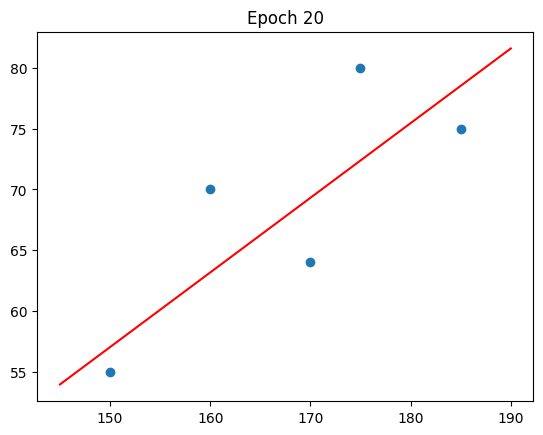

--------------------


In [ ]:
# 모델 파라미터 초기화
a = torch.tensor([0.45], requires_grad=True) # 역전파가 가능하게끔 설정
b = torch.tensor([-35.], requires_grad=True)

# 하이퍼파라미터 설정
LR = 3e-6
EPOCH = 20

loss_history = []

for ep in range(EPOCH):

    # inference
    y_hat = a * x + b # 모델을 이용한 예측 # a.b -> y_hat # +

    # loss
    loss = 0
    for n in range(N): # 참고로 N은 데이터 개수
        loss += (y[n] - y_hat[n])**2 # y_hat -> loss # +
    loss = loss/N # MSE # 5개 데이터에 대한 MSE

    # update
    loss.backward() # backpropagation(y_hat과 a.b에 대해서도 알고 있음) ++
    # 이를 통해 각 a.b에 대한 grad를 얻을 수 있음.

    with torch.no_grad(): # 이건 크게 신경쓰지 않아도 됨, 다음 역전파를 위한 초기화 과정 일부
        # 경사하강 ++
        a -= LR * a.grad # weight update
        b -= LR * b.grad # weight update

    # 이건 크게 신경쓰지 않아도 됨, 다음 역전파를 위한 초기화 과정
    a.grad = torch.tensor([0.]) # gradient 초기화
    b.grad = torch.tensor([0.]) # gradient 초기화

    # 출력 및 시각화
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {loss.item():.4f}")
    # print weight and bias
    print(f"Weight: {a.item():.4f}, Bias: {b.item():.4f}")
    # plot graph
    x_plot = torch.linspace(145, 190, 100)
    y_plot = a.detach() * x_plot + b.detach()
    plt.figure()
    plt.plot(x, y, 'o')
    plt.plot(x_plot, y_plot, 'r')
    plt.title(f"Epoch {ep+1}")
    plt.show()

    print("-"*20)

시간이 지남에 따라 점차 나아짐!!


- `.grad` 초기화 필요한 이유 실험

In [ ]:
# .grad 초기화 필요한 이유 실험
z = torch.tensor([1.],requires_grad=True)
for _ in range(2):
    loss = z**2
    loss.backward()
    print(z.grad)
    z.grad = torch.tensor([0.])
    # print(z.grad)

tensor([2.])
tensor([2.])


위에 보면 이전께 사라지지 않고 이전 값이 누적됨. 그래서 계속 0으로 초기화 시켜줘야함.

Text(0.5, 1.0, 'Training Loss')

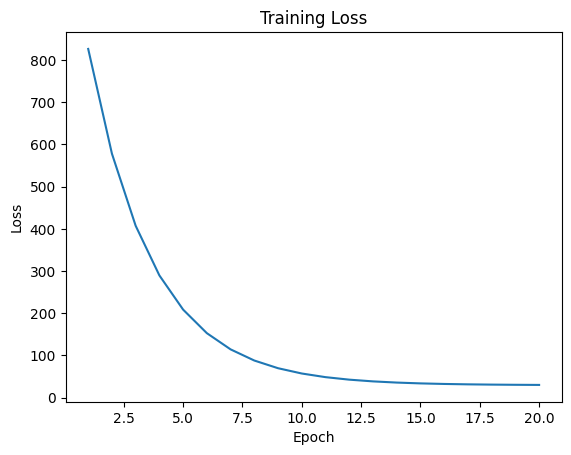

In [ ]:
# plot loss_history
plt.plot(range(1, EPOCH+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

## SGD 정석대로 코딩하기

Epoch: 1, train loss: 826.2250
Weight: 0.4785, Bias: -34.9998


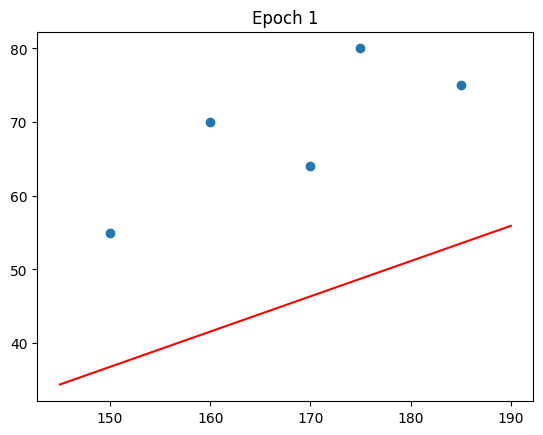

--------------------
Epoch: 2, train loss: 578.0414
Weight: 0.5022, Bias: -34.9997


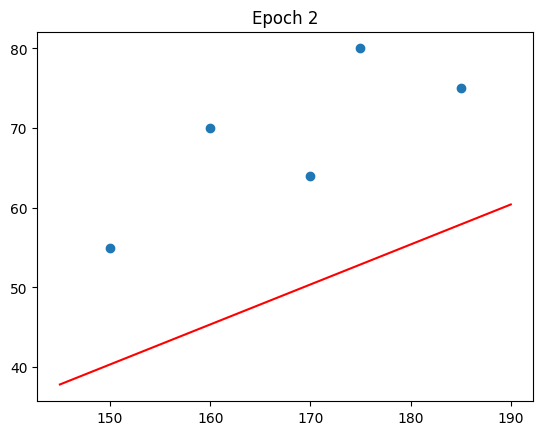

--------------------
Epoch: 3, train loss: 407.1602
Weight: 0.5218, Bias: -34.9996


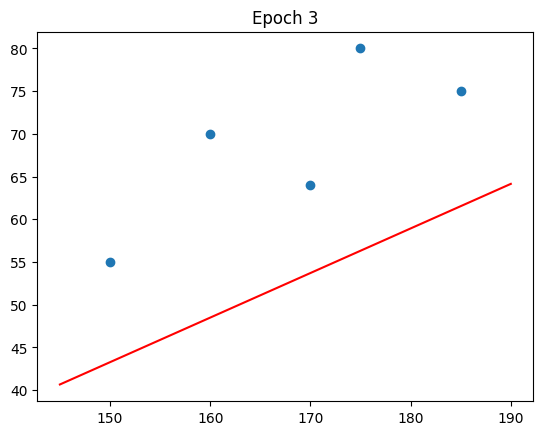

--------------------
Epoch: 4, train loss: 289.5042
Weight: 0.5381, Bias: -34.9995


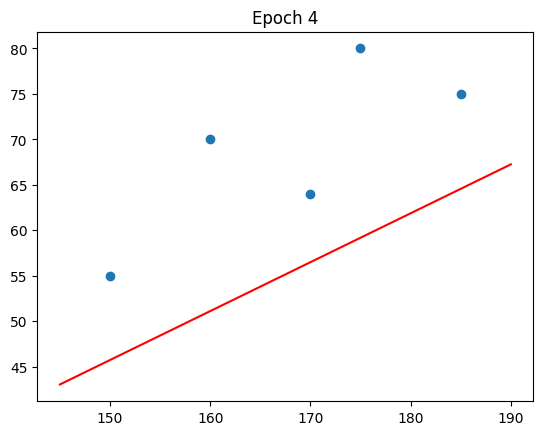

--------------------
Epoch: 5, train loss: 208.4954
Weight: 0.5517, Bias: -34.9994


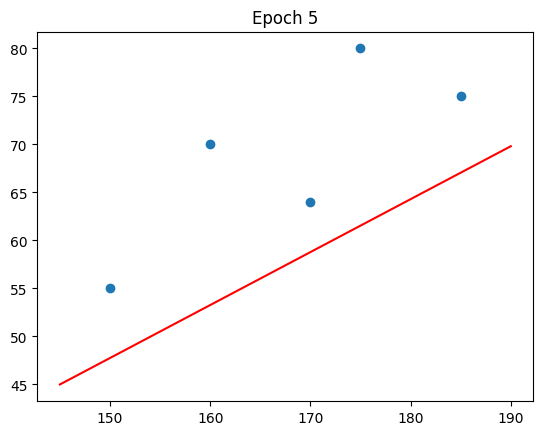

--------------------
Epoch: 6, train loss: 152.7187
Weight: 0.5629, Bias: -34.9993


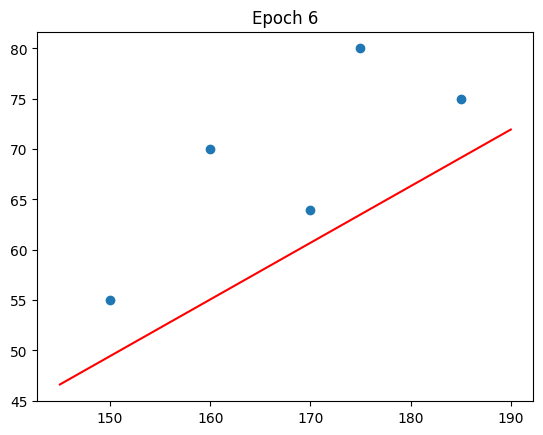

--------------------
Epoch: 7, train loss: 114.3153
Weight: 0.5722, Bias: -34.9993


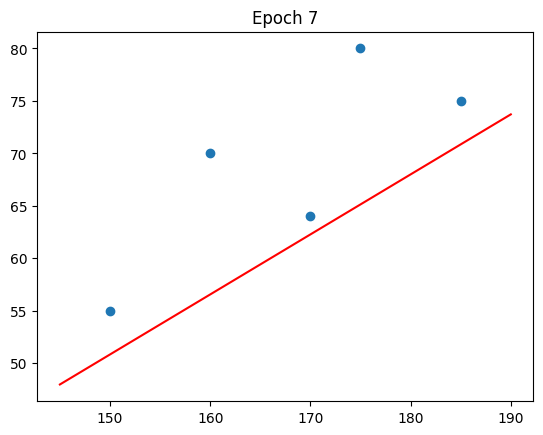

--------------------
Epoch: 8, train loss: 87.8735
Weight: 0.5799, Bias: -34.9992


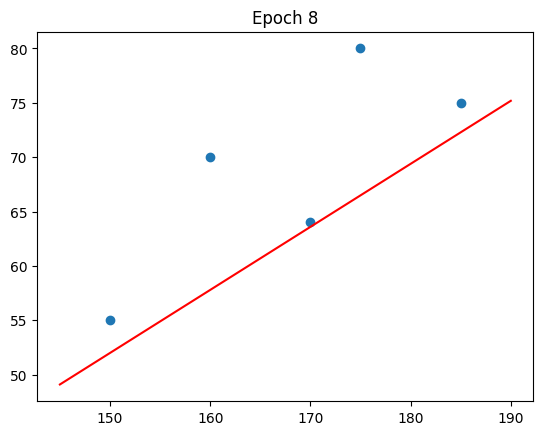

--------------------
Epoch: 9, train loss: 69.6676
Weight: 0.5863, Bias: -34.9992


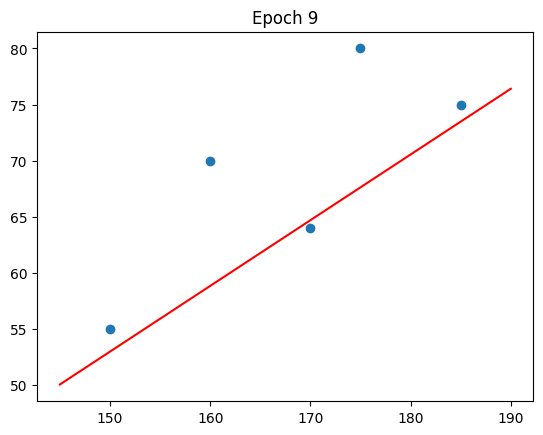

--------------------
Epoch: 10, train loss: 57.1324
Weight: 0.5917, Bias: -34.9992


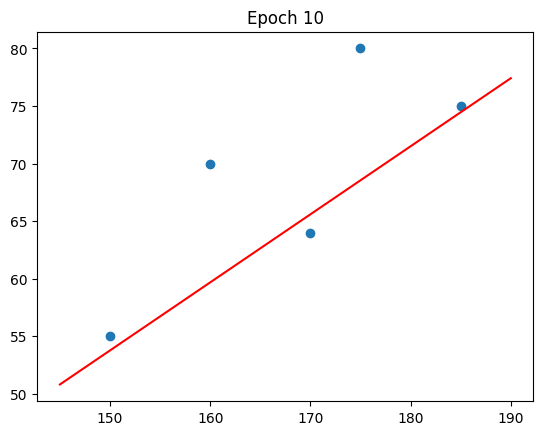

--------------------
Epoch: 11, train loss: 48.5017
Weight: 0.5961, Bias: -34.9991


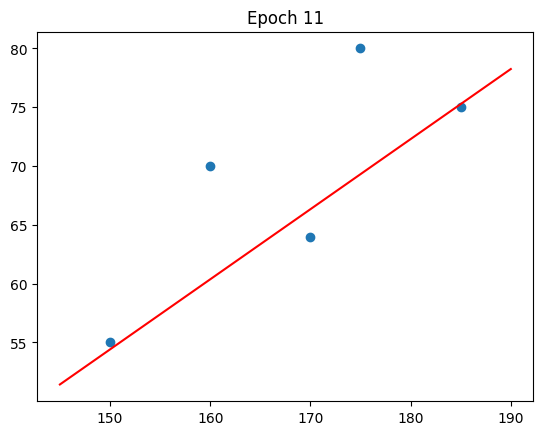

--------------------
Epoch: 12, train loss: 42.5591
Weight: 0.5997, Bias: -34.9991


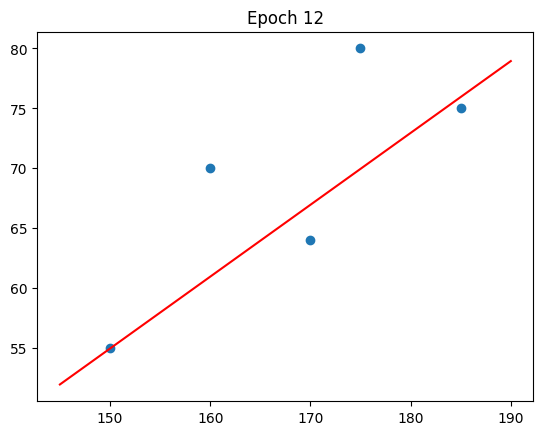

--------------------
Epoch: 13, train loss: 38.4676
Weight: 0.6028, Bias: -34.9991


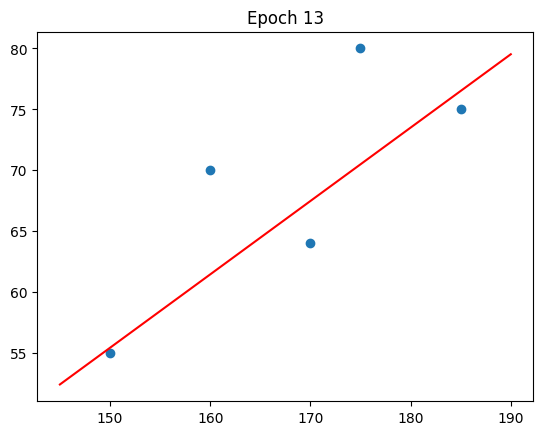

--------------------
Epoch: 14, train loss: 35.6504
Weight: 0.6053, Bias: -34.9991


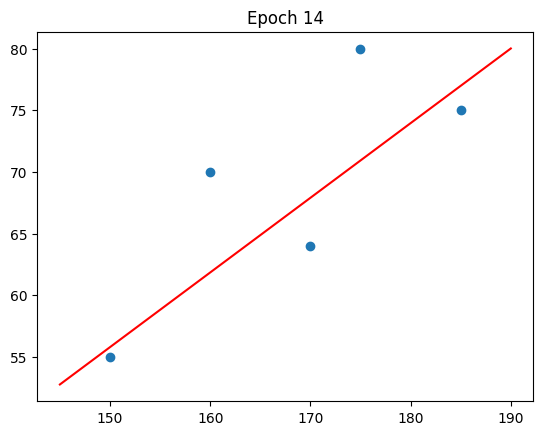

--------------------
Epoch: 15, train loss: 33.7107
Weight: 0.6074, Bias: -34.9991


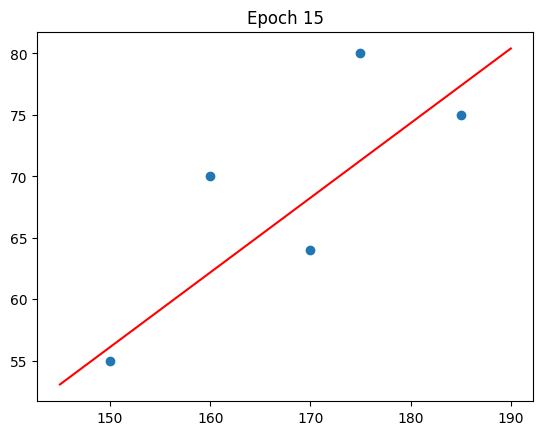

--------------------
Epoch: 16, train loss: 32.3752
Weight: 0.6091, Bias: -34.9991


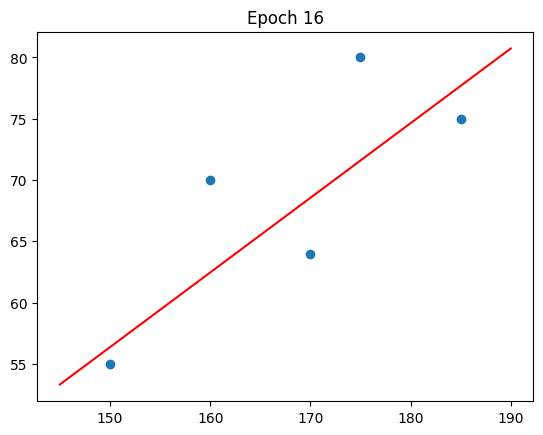

--------------------
Epoch: 17, train loss: 31.4557
Weight: 0.6106, Bias: -34.9990


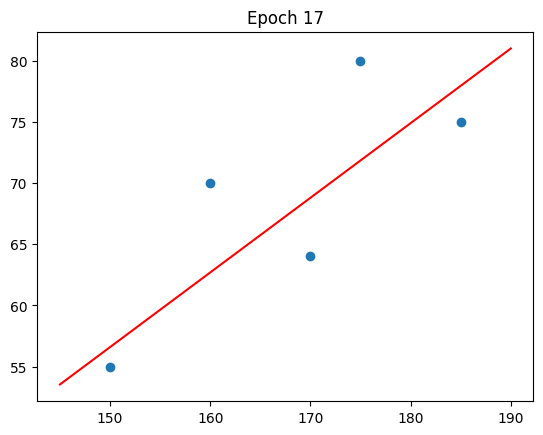

--------------------
Epoch: 18, train loss: 30.8225
Weight: 0.6118, Bias: -34.9990


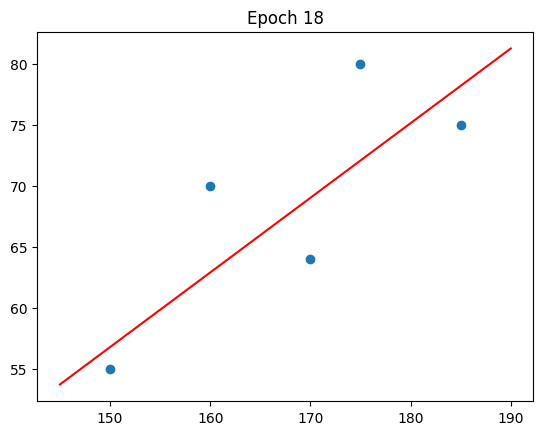

--------------------
Epoch: 19, train loss: 30.3866
Weight: 0.6127, Bias: -34.9990


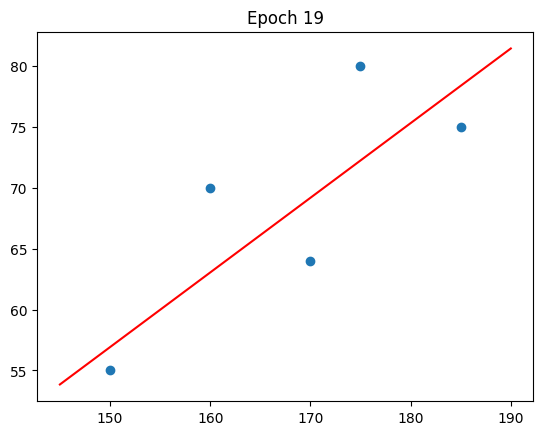

--------------------
Epoch: 20, train loss: 30.0865
Weight: 0.6136, Bias: -34.9990


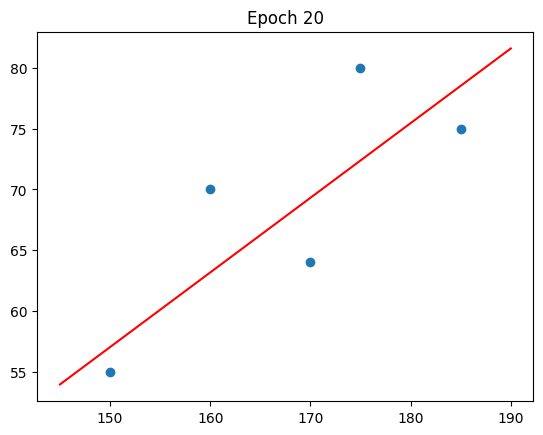

--------------------


In [ ]:
from torch import nn, optim # optime은 옵티마이저임

# 데이터 수 x 피쳐 수 형태로 바꿔줘야함.
x=x.reshape(-1,1) # 개채 형태로 바꿔줌 # 행 개수는 상관 없다(-1), 열만(피쳐) 1로 알라서 맞춰라.
y=y.reshape(-1,1) # x와 같은 형태로 바꿔줌 (MSELoss, BCELoss 는 y의 shape이 x의 shape과 같아야)

# model에 시작부터 파라미터들을 집어넣음, 여기서 집어넣기 때문에 뒤에서 일일히 작성할 필요 없누
model=nn.Linear(1,1)
model.weight.data = torch.tensor([[0.45]])
model.bias.data = torch.tensor([-35.])

LR = 3e-6
EPOCH = 20
optimizer = optim.SGD(model.parameters(), lr=LR) # SGD 옵티마이저 정의
# 이게 SGD? 아렵게 생각할거 없음. 이 상태에서 모든 데이터 집어 넣으면 GD고, 그게 아니면 SGD임.
# 이 SGD 옵티마이저가 다 해주는것
criterion = nn.MSELoss() # Loss도 어디서 MSE 함수를 가져와서 활용

loss_history=[]

for ep in range(EPOCH):
    # inference
    y_hat = model(x) # ++

    # loss
    loss = criterion(y_hat,y) # MSELoss ++

    # update
    optimizer.zero_grad() # gradient 누적을 막기 위한 초기화 # 원래 끝나고 했는데 여기서는 앞에서 먼저함
    loss.backward() # backpropagation 역전파 ++
    optimizer.step() # weight update ++

    # 결과물 출력, 안봐도 됨
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {loss.item():.4f}")
    # print weight and bias
    print(f"Weight: {model.weight.data.item():.4f}, Bias: {model.bias.data.item():.4f}")
    # plot graph
    x_plot=torch.linspace(145,190,100)
    y_plot=model.weight.squeeze().detach() * x_plot + model.bias.detach()
    plt.figure()
    plt.plot(x,y,'o')
    plt.plot(x_plot,y_plot,'r')
    plt.title(f"Epoch {ep+1}")
    plt.show()

    print("-"*20)

Text(0.5, 1.0, 'Training Loss')

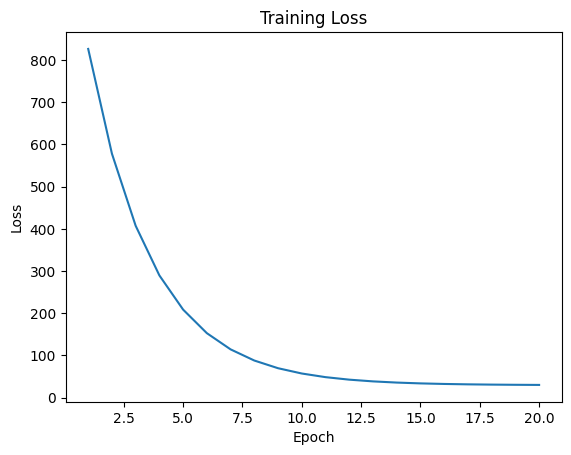

In [ ]:
# plot loss_history
plt.plot(range(1, EPOCH+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")